# 04 — Consolidated analysis

Everything that compares regions to each other, for **both** lines. Nothing here loads a
region for its own sake: it reads the `metrics.csv` files that `03A` and `03B` write in their
step 3, so a change to one region's thresholds means re-running that one block of `03A`, not
this notebook and not all five regions.

Two sections:

1. **Line A (NOAA)** — the cross-region summary, the 24 h fits, and the amplitude-vs-Wilson
   depression relation. This used to live at the tail of `03A` (cells 88–106), which meant
   analysing a single region also re-ran the conclusions for all of them.
2. **Line B (DS0N)** — amplitude estimators compared across DS00–DS09, and the correlations
   between amplitude, area and field.

### What changed from the previous version

- the hardcoded `/home/thomas/Projects/...` path is gone; paths come from `src.config`
  (the old one does not resolve from this working directory at all)
- the local `plot_time_series` that shadowed the `src` one is gone
- the three different DS lists (`00–09` in one cell, a hand-picked five in another, `00–11`
  on disk) are gone: `config.ds0n_regions()` reports whatever `DS<number>` directories are
  actually in `data/raw/sebastian_sun_spots/`
- the silent `nrows=250` truncation is now an explicit, named window
- `fft_amplitude`, `_prepare`, `sine_amplitude` and `mag_amplitude` moved into
  `src/spectra.py` and `src/oscillation.py`, where `03A` and `03B` can use them too

In [22]:
import pathlib
import sys

project_root = pathlib.Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root.resolve()))

import numpy as np
import pandas as pd

from src import comparison, config, oscillation, spectra

# Window for the amplitude estimators, in hours from each series' first frame.
# (0, 50) is about two 24 h cycles — the minimum for amplitude, phase and offset to
# separate. None uses the whole series, but then the spot crosses half the disk and the
# mean area stops being comparable between datasets.
WINDOW_H = (0.0, 50.0)
PERIOD_BAND_H = (16.0, 36.0)   # where to look for the "24 h" peak
SAVE = False
REMOVE_POLINOMIAL = True
REMOVE_JUMPS = True      # de-step what the reconstruction leaves behind

print(f'processed NOAA regions : {[p.name for p in config.processed_regions()]}')
DS0N_IDS = [d.name for d in config.ds0n_regions()]   # whatever is on disk, numeric order
print(f'DS0N datasets          : {DS0N_IDS}')

processed NOAA regions : ['NOAA_11106_2010-09-16', 'NOAA_11117_2010-10-27', 'NOAA_11363_2011-12-06', 'NOAA_11536_2012-07-31', 'NOAA_13131_2022-10-29']
DS0N datasets          : ['DS00', 'DS01', 'DS02', 'DS03', 'DS04', 'DS05', 'DS06', 'DS07', 'DS08', 'DS09', 'DS10', 'DS11', 'DS13', 'DS15', 'DS17', 'DS19', 'DS21', 'DS23', 'DS25', 'DS27', 'DS29', 'DS31', 'DS33', 'DS35', 'DS37', 'DS39', 'DS41', 'DS43', 'DS45', 'DS49', 'DS51']


---

# Line A — NOAA

## The regions, side by side

Loaded once here and reused by every cell below.

In [23]:
from src.analysis import compute_metrics
from src.loaders import load_noaa_region
from src.post_processing import reconstruct_cubes

all_metrics = {}
for region_dir in config.processed_regions():
    params = config.params_for(region_dir)
    d = load_noaa_region(region_dir, raw_dir=config.RAW_DIR / region_dir.name,
                         **config.loader_kwargs(params))
    if REMOVE_POLINOMIAL:
        new_dop, new_mag= reconstruct_cubes(
            d['cube_dop'], d['cube_mag'], d['timestamps'],
        )
        # Inside the `if`: matches 03A's step 1.5 exactly, so Line A here is the same
        # reconstruction 03A shows, not the pre-reconstruction cubes on disk.
        d['cube_dop'], d['cube_mag'] = new_dop, new_mag
    all_metrics[region_dir.name] = (d, compute_metrics(d))
    print(f'{region_dir.name}: {d["n_t"]} frames, {d["time_h"][-1]:.1f} h')

summary = pd.DataFrame(comparison.region_summary_rows(all_metrics))
summary

2026-09-15 14:46:41 - astropy - WARNING: TimeDeltaMissingUnitWarning: Numerical value without unit or explicit format passed to TimeDelta, assuming days
/mnt/shared/Projects/sun_spots_pulsation_review/src/post_processing.py:170: RuntimeWarning: invalid value encountered in sqrt
  r = 2 * np.sqrt(-p3 / 3)
/mnt/shared/Projects/sun_spots_pulsation_review/src/post_processing.py:171: RuntimeWarning: invalid value encountered in sqrt
  arg = np.clip((3 * q3) / (2 * p3) * np.sqrt(-3 / p3), -1.0, 1.0)


480 frame(s) matched to 6 coefficient window(s)


/mnt/shared/Projects/sun_spots_pulsation_review/src/analysis.py:306: RuntimeWarning: Mean of empty slice
  f'mean_mag_quiet{mag_variant}' : np.array([np.nanmean(mag_qsun_src[t], dtype=np.float64) for t in range(n_qsun)]),
/mnt/shared/Projects/sun_spots_pulsation_review/src/analysis.py:310: RuntimeWarning: Mean of empty slice
  'mean_dop_quiet': np.array([np.nanmean(cube_dop_qsun[t], dtype=np.float64) for t in range(n_qsun)]),


NOAA_11106_2010-09-16: 480 frames, 95.8 h


2026-09-15 14:47:06 - astropy - WARNING: TimeDeltaMissingUnitWarning: Numerical value without unit or explicit format passed to TimeDelta, assuming days
/mnt/shared/Projects/sun_spots_pulsation_review/src/post_processing.py:170: RuntimeWarning: invalid value encountered in sqrt
  r = 2 * np.sqrt(-p3 / 3)
/mnt/shared/Projects/sun_spots_pulsation_review/src/post_processing.py:171: RuntimeWarning: invalid value encountered in sqrt
  arg = np.clip((3 * q3) / (2 * p3) * np.sqrt(-3 / p3), -1.0, 1.0)


...

/mnt/shared/Projects/sun_spots_pulsation_review/src/analysis.py:310: RuntimeWarning: Mean of empty slice
  'mean_dop_quiet': np.array([np.nanmean(cube_dop_qsun[t], dtype=np.float64) for t in range(n_qsun)]),


NOAA_11536_2012-07-31: 481 frames, 96.0 h


2026-09-15 14:47:40 - astropy - WARNING: TimeDeltaMissingUnitWarning: Numerical value without unit or explicit format passed to TimeDelta, assuming days


481 frame(s) matched to 12 coefficient window(s)
NOAA_13131_2022-10-29: 481 frames, 96.0 h


,region,n_frames,span_h,cadence_s,area_umb_mean,area_pen_mean,mean_dop_umb_mean,mean_dop_quiet_mean,mean_mag_umb_mean,mean_mag_hotspot_mean,dop_umb_minus_quiet_mean
0,NOAA_11106_2010-09-16,480,95.8,720.0,217.643805,774.825221,264.241008,-270.718669,10486.655150,9402.378566,534.959678
1,NOAA_11117_2010-10-27,481,96.0,720.0,1406.669474,5259.208421,-1453.508396,-313.944042,-8889.692081,-7356.671839,-1139.564355
2,NOAA_11363_2011-12-06,481,96.0,720.0,1305.000000,5352.290188,11510.485312,-320.304550,3659.671209,3551.273642,11830.725988
3,NOAA_11536_2012-07-31,481,96.0,720.0,130.112266,497.461538,2182.393470,-235.074599,14096.376904,12302.429556,2417.468069
4,NOAA_13131_2022-10-29,481,96.0,720.0,1000.355509,4884.667360,-4222.859970,-276.532505,-7657.760984,-6595.959047,-3946.327465


In [24]:
if REMOVE_POLINOMIAL:
    pass
    #all_metrics.pop('NOAA_11363_2011-12-06', None) #this region failed to be analized so its removed in the case of re
    #all_metrics.pop('NOAA_13131_2022-10-29', None) 

## Removing the steps the reconstruction leaves behind

`reconstruct_cubes` inverts HMI's calibration cubic one frame at a time, and among the
three real roots it picks the one nearest the measured value. Nothing ties that choice to
the frame before it, so when a new `hmi.coefficients` row takes over — a new one starts
every 12 h — the choice can land on a different branch and the series steps by the branch
separation: thousands of m/s between adjacent frames.

`spectra.remove_jumps` finds those steps by their slope and subtracts them, using the slope
either side to keep the curve continuous instead of flattening the interval. Steps landing
near a multiple of 12 h are the signature of the coefficient windows — the dashed grey
lines below mark them. Steps anywhere else are something different and worth a look.

**This is conditioning, not a repair.** Each segment keeps whatever branch it was
reconstructed on, so after the first step only *relative* levels mean anything: the
absolute velocity of a later segment is still whatever the wrong branch gave it.

In [25]:
# Every mean series the reconstruction touched. Areas are left out — they come from the
# continuum masks, which cell 3 never rewrote.
JUMP_KEYS = ('mean_dop_umb', 'mean_dop_pen', 'mean_dop_both', 'mean_dop_quiet',
             'mean_mag_umb', 'mean_mag_pen', 'mean_mag_both', 'mean_mag_quiet',
             'mean_mag_hotspot')

pre_jump, jump_tables, rows = {}, [], []
if REMOVE_JUMPS:
    for name, (d, m) in all_metrics.items():
        pre_jump[name] = {}
        for key in JUMP_KEYS:
            # The quiet-sun series come from the untouched qsun cubes and should report no
            # steps at all; running them through anyway is a free check that the filter is
            # not inventing any.
            if key not in m or len(m[key]) != len(d['time_h']):
                continue
            before = m[key].copy()
            pre_jump[name][key] = before
            m[key], jumps = spectra.remove_jumps(d['time_h'], before)
            if jumps.empty:
                continue
            jump_tables.append(jumps.assign(region=name, key=key))
            offsets = jumps['offset'].to_numpy()
            rows.append(dict(
                region=name, key=key, n_jumps=len(jumps),
                largest=np.abs(offsets).max(),
                # Consecutive offsets of opposite sign mean the inversion is flipping back
                # and forth frame to frame rather than settling on a new level. A high
                # fraction here says the series is thrashing, and de-stepping it is not
                # the right description of what is wrong with it.
                alternating=(np.diff(np.sign(offsets)) != 0).mean() if len(offsets) > 1 else 0.0,
                step_before=np.nanmax(np.abs(np.diff(before))),
                step_after=np.nanmax(np.abs(np.diff(m[key]))),
            ))

    if rows:
        jump_table = pd.concat(jump_tables, ignore_index=True)[
            ['region', 'key', 'index', 'time', 'step', 'expected', 'offset']]
        print(pd.DataFrame(rows).to_string(index=False,
                                           float_format=lambda v: f'{v:.2f}'))
        print(f'\n{len(jump_table)} step(s) removed in total. '
              'The full per-step listing is in `jump_table`.')
    else:
        jump_table = pd.DataFrame()
        print('no steps found — nothing to correct')

               region              key  n_jumps   largest  alternating  step_before  step_after
NOAA_11117_2010-10-27     mean_mag_umb        4   1504.07         0.67      1526.38      298.19
NOAA_11117_2010-10-27    mean_mag_both        1    712.02         0.00       725.15      379.14
NOAA_11117_2010-10-27 mean_mag_hotspot        1   1243.77         0.00      1268.95      407.36
NOAA_11363_2011-12-06     mean_dop_umb       14 115264.66         0.54    115205.69      527.23
NOAA_11363_2011-12-06     mean_dop_pen       21 118642.04         0.70    118547.26     2428.54
NOAA_11363_2011-12-06    mean_dop_both       20 117970.60         0.74    117883.60     2048.95
NOAA_11363_2011-12-06     mean_mag_umb        9  78631.33         0.62     78666.44      341.45
NOAA_11363_2011-12-06     mean_mag_pen       10  41120.15         0.56     41120.09      800.69
NOAA_11363_2011-12-06    mean_mag_both       12  48557.16         0.82     48575.12      735.38
NOAA_11363_2011-12-06 mean_mag_hotspot  

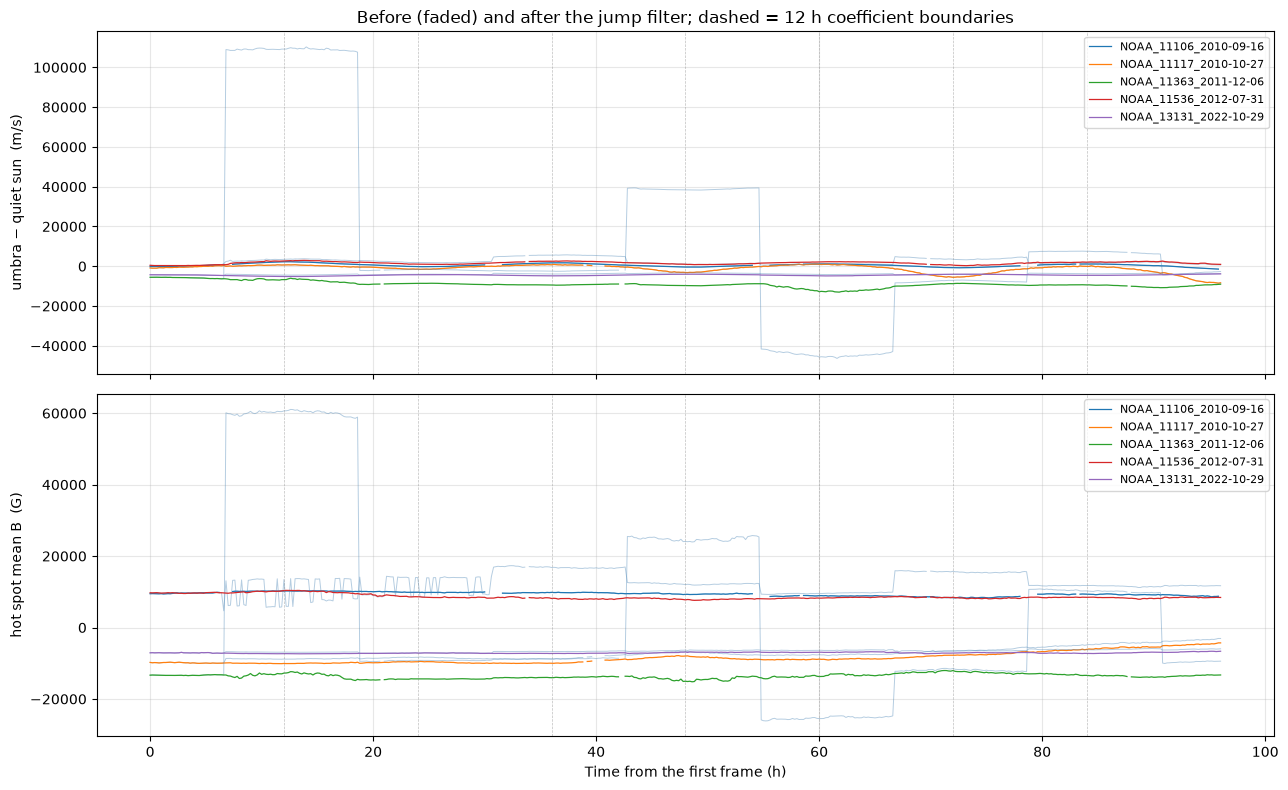

In [26]:
import matplotlib.pyplot as plt

if REMOVE_JUMPS and pre_jump:
    fig, (ax_v, ax_b) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
    for name, (d, m) in all_metrics.items():
        before = pre_jump[name]
        ax_v.plot(d['time_h'], before['mean_dop_umb'] - before['mean_dop_quiet'],
                  lw=0.7, color='steelblue', alpha=0.4)
        ax_v.plot(d['time_h'], m['mean_dop_umb'] - m['mean_dop_quiet'], lw=0.9, label=name)
        if 'mean_mag_hotspot' in before:
            ax_b.plot(d['time_h'], before['mean_mag_hotspot'],
                      lw=0.7, color='steelblue', alpha=0.4)
            ax_b.plot(d['time_h'], m['mean_mag_hotspot'], lw=0.9, label=name)

    t_max = max(d['time_h'][-1] for d, _ in all_metrics.values())
    for ax in (ax_v, ax_b):
        for boundary in np.arange(12, t_max, 12):
            ax.axvline(boundary, color='grey', ls='--', lw=0.5, alpha=0.5)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

    ax_v.set_ylabel('umbra − quiet sun  (m/s)')
    ax_v.set_title('Before (faded) and after the jump filter; dashed = 12 h coefficient '
                   'boundaries')
    ax_b.set_ylabel('hot spot mean B  (G)')
    ax_b.set_xlabel('Time from the first frame (h)')
    plt.tight_layout()
    plt.show()

## Umbral velocity and hot-spot field, all regions on shared axes

The point of overlaying them is the phase: if every region's umbra rises and falls together,
what they share is the observatory, not the Sun.

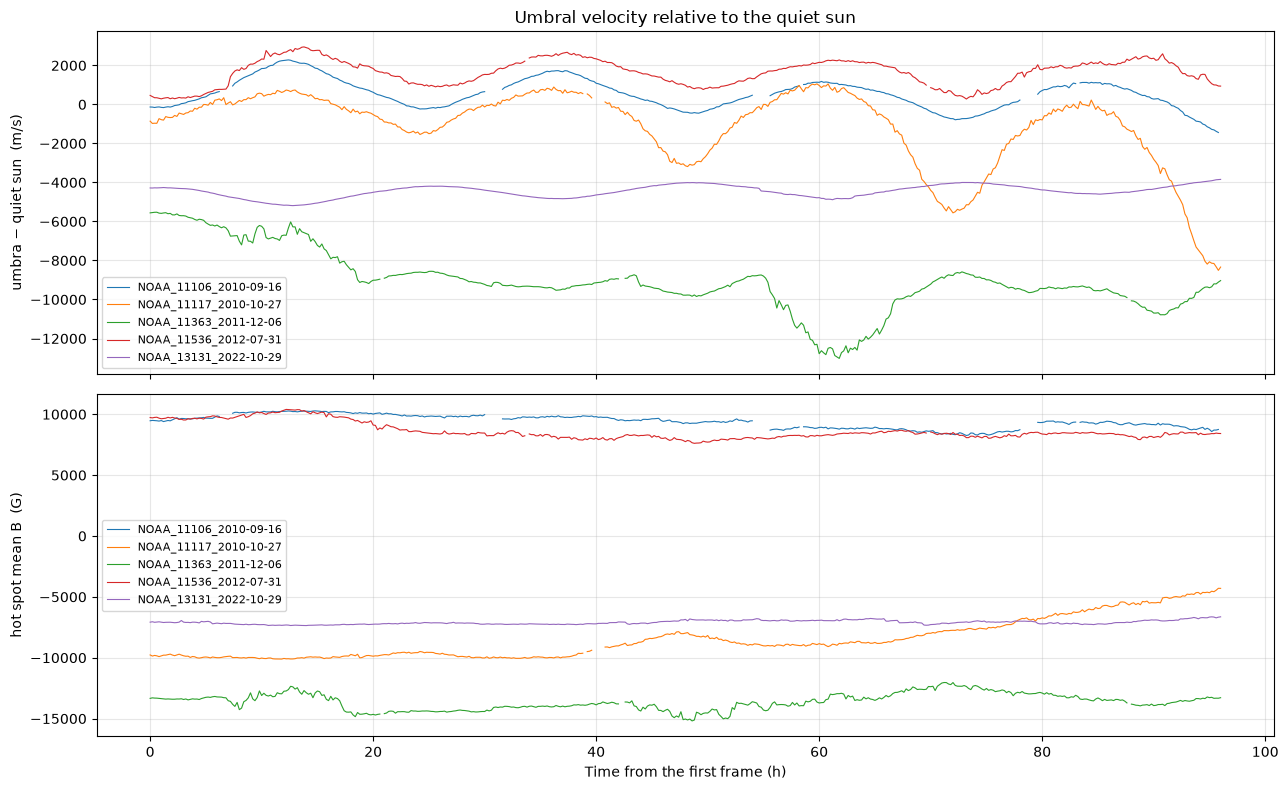

In [27]:
import matplotlib.pyplot as plt

fig, (ax_v, ax_b) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for name, (d, m) in all_metrics.items():
    ax_v.plot(d['time_h'], m['mean_dop_umb'] - m['mean_dop_quiet'], lw=0.8, label=name)
    if 'mean_mag_hotspot' in m:
        ax_b.plot(d['time_h'], m['mean_mag_hotspot'], lw=0.8, label=name)

ax_v.set_ylabel('umbra − quiet sun  (m/s)')
ax_v.set_title('Umbral velocity relative to the quiet sun')
ax_b.set_ylabel('hot spot mean B  (G)')
ax_b.set_xlabel('Time from the first frame (h)')
for ax in (ax_v, ax_b):
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## The 24 h fit, per region

`fit_diurnal` is a linear least-squares fit of `c + a·sin(2πt/P) + b·cos(2πt/P)` at a
**fixed** period, giving `amplitude = hypot(a, b)` with a real uncertainty.

Two fits per region, over **identical points**:

- **absolute** umbral velocity
- **umbra − quiet sun**

That pair is the instrumental control. Over the same mask the linear fit of `(umbra − quiet)`
is exactly the fit of umbra minus the fit of quiet, so the ratio of the two amplitudes says
how much of the signal is umbral and how much moved the whole box together. At a 24 h period,
"the whole box together" points at residual SDO orbital velocity rather than at the sunspot.

The windows and the Löptien reference table are in `src/config.py`. NOAA 11117 appears twice
because the table does: 2010-10-27 and 2010-10-28 are one continuous passage in a single
cube, so its two rows are the 0–24 h and 24–48 h stretches and give two independent points.

In [28]:
by_noaa = {config.region_noaa(pathlib.Path(name)): (name, d, m)
           for name, (d, m) in all_metrics.items()}

fit_rows, skipped = [], []
for noaa, date, theta, area_mm2, b_av, z_div, z_press in config.LOPTIEN_TABLE:
    window = config.FIT_WINDOWS.get((noaa, date))
    if noaa not in by_noaa:
        skipped.append(f'NOAA {noaa} {date}: no processed cube')
        continue
    if window is None:
        skipped.append(f'NOAA {noaa} {date}: no entry in config.FIT_WINDOWS')
        continue

    region_name, d, m = by_noaa[noaa]
    time_h = d['time_h']
    v_abs = m['mean_dop_umb']
    v_rel = m['mean_dop_umb'] - m['mean_dop_quiet']
    label = f'NOAA {noaa} {date}'

    # One shared mask for both fits — this is what makes the two amplitude columns a real
    # control rather than two loosely related numbers.
    shared = np.isfinite(v_abs) & np.isfinite(v_rel)

    fit_abs = oscillation.fit_diurnal(time_h, v_abs, window=window,
                                      period_h=config.FIT_PERIOD_H, mask=shared,
                                      label=f'{label} abs')
    fit_rel = oscillation.fit_diurnal(time_h, v_rel, window=window,
                                      period_h=config.FIT_PERIOD_H, mask=shared,
                                      label=f'{label} rel')

    fit_rows.append(dict(label=label, noaa=noaa, date=date, region=region_name,
                         window=window, theta_deg=theta, area_mm2=area_mm2, b_av=b_av,
                         z_div=z_div, z_press=z_press, time_h=time_h,
                         series=v_abs, series_rel=v_rel,
                         fit_abs=fit_abs, fit_rel=fit_rel))

for note in skipped:
    print(f'  skipped  {note}')

print()
header = (f'{"region":22s} {"window":>12s} {"n":>4s} | {"intercept":>10s} '
          f'{"amplitude":>16s} {"t_max":>7s} {"rms":>7s} | {"intercept":>10s} {"amplitude":>16s}')
print(f'{"":22s} {"":>12s} {"":>4s} | {"--- umbra, absolute (m/s) ---":^43s} | '
      f'{"--- umbra - quiet sun (m/s) ---":^29s}')
print(header)
print('-' * len(header))
for row in fit_rows:
    a, r = row['fit_abs'], row['fit_rel']
    t0, t1 = row['window']
    print(f'{row["label"]:22s} {f"{t0:.0f}-{t1:.0f}":>12s} {a["n"]:4d} | '
          f'{a["intercept"]:10.1f} {a["amplitude"]:8.1f} ± {a["sigma_amplitude"]:5.1f} '
          f'{a["t_max"]:7.1f} {a["rms_residual"]:7.1f} | '
          f'{r["intercept"]:10.1f} {r["amplitude"]:8.1f} ± {r["sigma_amplitude"]:5.1f}')

print()
for row in fit_rows:
    a, r = row['fit_abs']['amplitude'], row['fit_rel']['amplitude']
    if np.isfinite(a) and a > 0:
        note = '   <- mostly common to the whole box' if r / a < 0.5 else ''
        print(f'  {row["label"]:22s} umbral fraction of the amplitude: {r / a:.2f}{note}')

  skipped  NOAA 11039 2010-01-01: no processed cube
  skipped  NOAA 11041 2010-01-26: no processed cube

                                         |        --- umbra, absolute (m/s) ---        | --- umbra - quiet sun (m/s) ---
region                       window    n |  intercept        amplitude   t_max     rms |  intercept        amplitude
--------------------------------------------------------------------------------------------------------------------
NOAA 11106 2010-09-16          0-24  116 |      704.9   1124.8 ±  12.5    12.7    96.4 |      945.8   1121.5 ±  12.4
NOAA 11117 2010-10-27          0-24  121 |     -480.8    802.0 ±  22.9    11.2   176.2 |     -163.2    813.1 ±  22.7
NOAA 11117 2010-10-28         24-48  115 |     -764.5   1382.5 ±  57.0    35.4   436.2 |     -448.6   1388.2 ±  57.0
NOAA 11363 2011-12-06          0-24  120 |    -7393.4   1268.2 ± 103.5     6.8   787.2 |    -7117.1   1255.8 ± 102.6
NOAA 11536 2012-07-31          0-24  121 |     1430.9   1194.5 ±  27.6  

/tmp/ipykernel_19428/3640204287.py:24: UserWarning: fit_diurnal [NOAA 11106 2010-09-16 abs]: the 24 h window is only 1.00 periods long. Amplitude, phase and intercept are poorly separated over so little of a cycle — read sigma_amplitude before reading amplitude.
  fit_abs = oscillation.fit_diurnal(time_h, v_abs, window=window,
/tmp/ipykernel_19428/3640204287.py:27: UserWarning: fit_diurnal [NOAA 11106 2010-09-16 rel]: the 24 h window is only 1.00 periods long. Amplitude, phase and intercept are poorly separated over so little of a cycle — read sigma_amplitude before reading amplitude.
  fit_rel = oscillation.fit_diurnal(time_h, v_rel, window=window,
/tmp/ipykernel_19428/3640204287.py:24: UserWarning: fit_diurnal [NOAA 11117 2010-10-27 abs]: the 24 h window is only 1.00 periods long. Amplitude, phase and intercept are poorly separated over so little of a cycle — read sigma_amplitude before reading amplitude.
  fit_abs = oscillation.fit_diurnal(time_h, v_abs, window=window,
/tmp/ipykerne

Saved next to the cubes, one row per table entry, so the numbers can be re-read without
re-running any of this.

In [29]:
fit_csv = config.PROCESSED_DIR / 'diurnal_fits.csv'
pd.DataFrame([{
    'label': row['label'], 'noaa': row['noaa'], 'date': row['date'],
    'region': row['region'], 'period_h': config.FIT_PERIOD_H,
    'window_start_h': row['window'][0], 'window_end_h': row['window'][1],
    'n_points': row['fit_abs']['n'],
    'theta_deg': row['theta_deg'], 'area_mm2': row['area_mm2'], 'b_av_G': row['b_av'],
    'z_div_km': row['z_div'], 'z_press_km': row['z_press'],
    **{f'{k}_abs': row['fit_abs'][k] for k in
       ('intercept', 'amplitude', 'sigma_intercept', 'sigma_amplitude', 't_max', 'rms_residual')},
    **{f'{k}_rel': row['fit_rel'][k] for k in
       ('intercept', 'amplitude', 'sigma_intercept', 'sigma_amplitude', 't_max', 'rms_residual')},
} for row in fit_rows]).to_csv(fit_csv, index=False, float_format='%.4f')
print(f'Fits saved → {fit_csv}  ({len(fit_rows)} rows)')

Fits saved → /mnt/shared/Projects/sun_spots_pulsation_review/data/processed/diurnal_fits.csv  (6 rows)


## The fits themselves

Always look at these before reading anything off the scatter below: a fit with a large `rms`
or a window covering barely one period will still return a confident-looking amplitude.

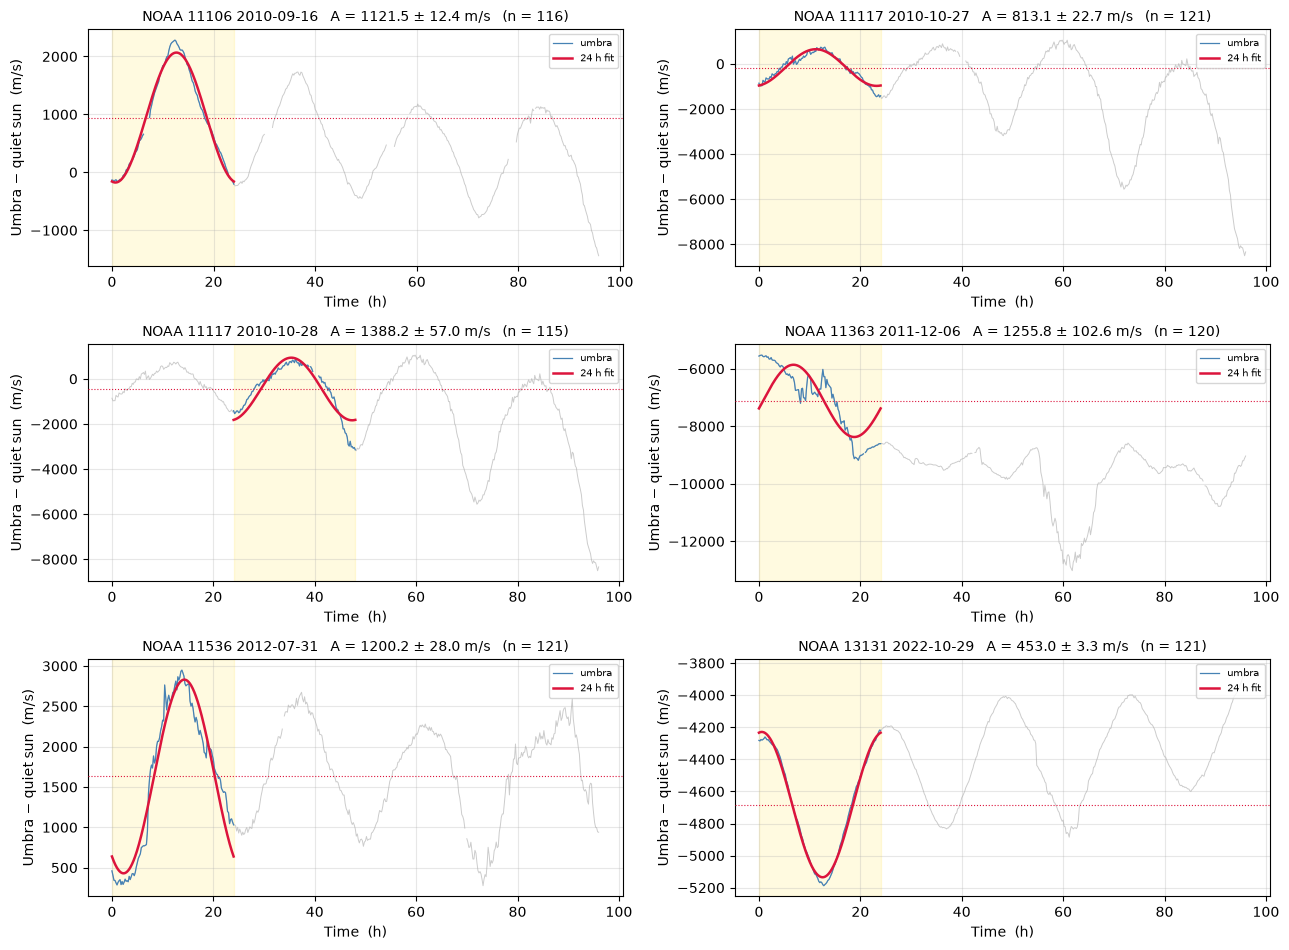

In [30]:
comparison.plot_diurnal_fits(fit_rows, series_key='fit_rel', save=SAVE,
                             plots_dir=config.PROCESSED_DIR / 'plots')

## Amplitude vs Wilson depression

The scientific payoff of line A: the fitted 24 h umbral Doppler amplitude against the Wilson
depression Löptien et al. measured with Hinode by a completely independent method.



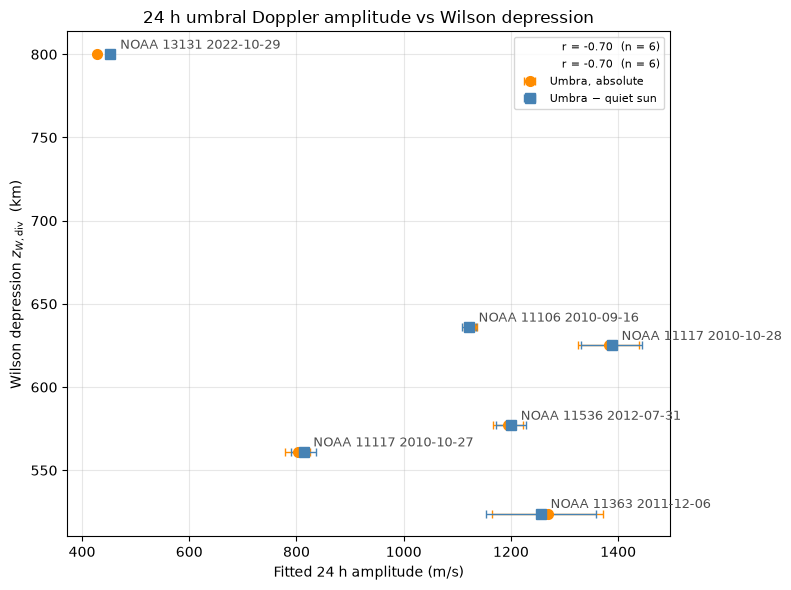

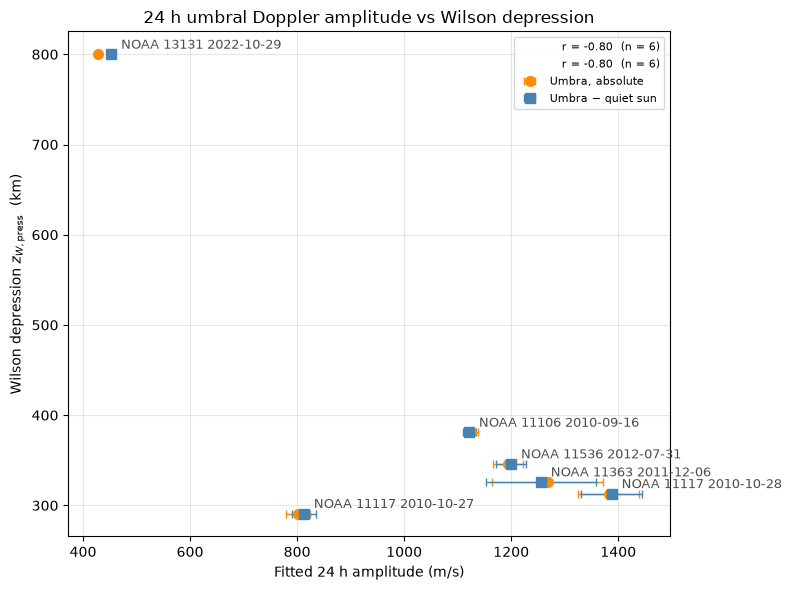

In [31]:
plots_dir = config.PROCESSED_DIR / 'plots'
comparison.plot_amplitude_vs_depression(fit_rows, depth_key='z_div', save=SAVE, plots_dir=plots_dir)
comparison.plot_amplitude_vs_depression(fit_rows, depth_key='z_press', save=SAVE, plots_dir=plots_dir)

### Amplitude vs area

Plotting amplitude against **1/area** described the sample better than normalising the
amplitude *by* area, which over-fitted it. Both are here so the difference is visible rather
than remembered.

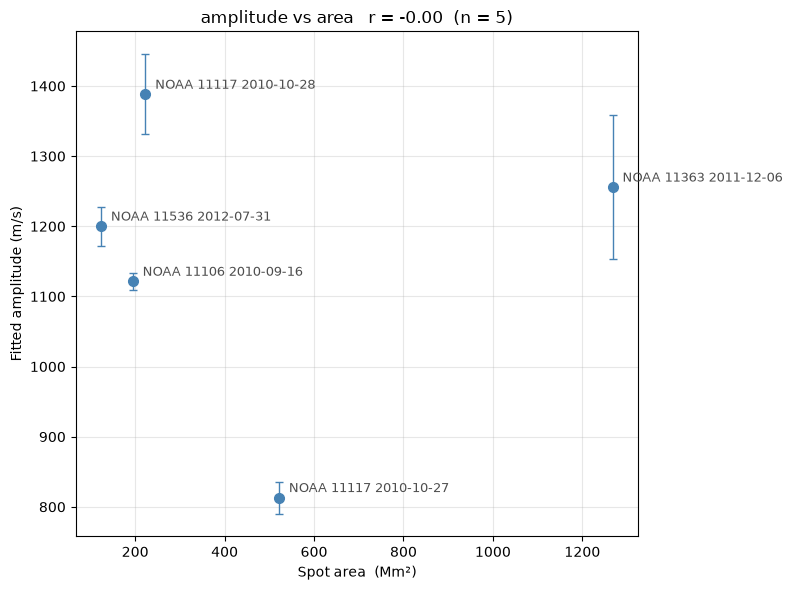

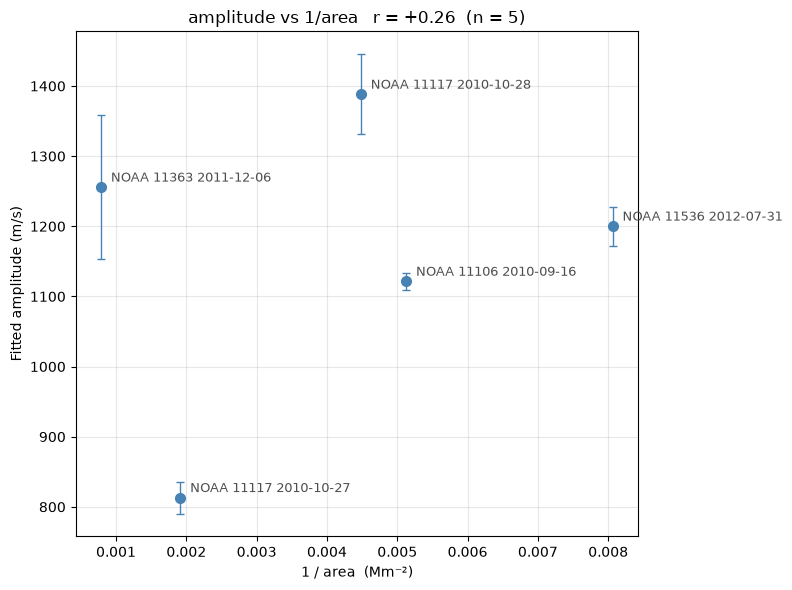

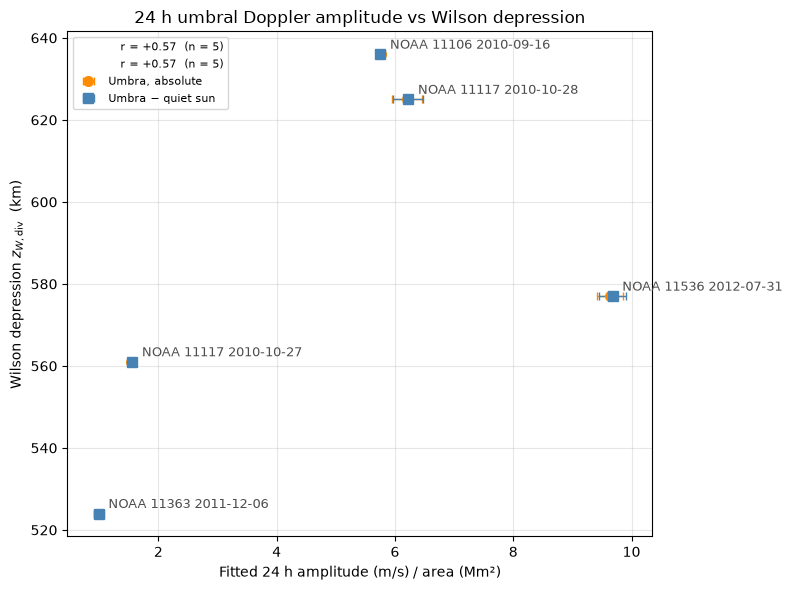

In [32]:
comparison.plot_amplitude_vs_area(fit_rows, inverse=False, save=SAVE, plots_dir=plots_dir)
comparison.plot_amplitude_vs_area(fit_rows, inverse=True, save=SAVE, plots_dir=plots_dir)
comparison.plot_amplitude_vs_depression(fit_rows, depth_key='z_div', normalize_area=True,
                                        save=SAVE, plots_dir=plots_dir)

---

# Line B — DS0N

Read from the `metrics.csv` files `03B` writes, so nothing is loaded from a cube here.

In [33]:
# One spot per row: a lettered variant (DS00_A, DS00_B) supersedes its base, which is the
# older whole-box run. `DS01_RemPol` is a processing experiment, not a second spot, so it is
# neither a variant nor a dataset of its own — it is listed as skipped rather than dropped
# silently. Same rule, same helper, as the summary page.
from src import report

chosen = report.datasets_to_show(config.DS0N_PROCESSED_DIR,
                                 has_data=lambda d: (d / 'metrics.csv').exists())

osc_dfs = {}
for ds_dir in chosen:
    df = pd.read_csv(ds_dir / 'metrics.csv')
    # 03B names the field columns `_absolute` when it averaged |B| instead of signed B.
    # Rename on the way in so everything below reads one stable name whichever run wrote it.
    absolute = {c: c.removesuffix('_absolute') for c in df.columns if c.endswith('_absolute')}
    osc_dfs[ds_dir.name] = df.rename(columns=absolute)
    print(f'  {ds_dir.name:10s} {len(df):5d} rows, {df["time_h"].iloc[-1]:6.1f} h'
          f'{"  (|B|)" if absolute else "  (signed B)"}')

on_disk = {d.name for d in config.DS0N_PROCESSED_DIR.iterdir() if d.is_dir()}
skipped = sorted(on_disk - {d.name for d in chosen})
print(f'\n{len(osc_dfs)} dataset(s) loaded')
print(f'skipped: {", ".join(skipped)}')

  DS00_A       900 rows,  205.6 h  (|B|)
  DS00_B       900 rows,  205.6 h  (|B|)
  DS01        1067 rows,  217.8 h  (|B|)
  DS02        1076 rows,  226.8 h  (|B|)
  DS03        1084 rows,  221.8 h  (|B|)
  DS04        1069 rows,  217.8 h  (|B|)
  DS05        1087 rows,  221.8 h  (|B|)
  DS06_A       958 rows,  225.8 h  (|B|)
  DS06_B       958 rows,  225.8 h  (|B|)
  DS07_A       684 rows,  153.2 h  (|B|)
  DS08_A       799 rows,  177.2 h  (|B|)
  DS08_B       799 rows,  177.2 h  (|B|)
  DS09         992 rows,  207.8 h  (|B|)
  DS13         962 rows,  194.8 h  (|B|)
  DS15        1317 rows,  269.8 h  (|B|)
  DS17         971 rows,  205.2 h  (|B|)
  DS19        1277 rows,  262.2 h  (|B|)
  DS21        1206 rows,  245.8 h  (|B|)
  DS23         952 rows,  200.0 h  (|B|)
  DS25        1208 rows,  252.8 h  (|B|)
  DS27_A      1045 rows,  218.8 h  (|B|)
  DS27_B       707 rows,  149.8 h  (|B|)
  DS29        1075 rows,  224.8 h  (|B|)
  DS31        1205 rows,  269.8 h  (|B|)
  DS33        11

## Three amplitude estimators, compared

`max − min` is a bad amplitude estimator: it is contaminated by any surviving trend, by gaps,
and by a single outlier. It is kept here only so the newer numbers stay comparable with the
older ones.

- **`peak_to_peak`** — detrend, then half of (max − min)
- **`fft_amplitude`** — Hann window, zero-padded, coherent-gain corrected, peak searched
  inside the 16–36 h band
- **`fit_amplitude`** — a sinusoidal fit at the period the spectrum found, with a real sigma

`n_cycles` is the one to check first: below about 1.5, the window does not constrain an
amplitude no matter which estimator produced it.

In [34]:
# The whole-window estimators: WINDOW_H (0-50 h) is about two cycles, and the fit takes
# the period the spectrum found rather than assuming 24 h.
#
# The sinusoidal fit is `D sin(2 pi t / P + phi) + b t + c` — the line is fitted *with* the
# sinusoid, not subtracted beforehand. A spot drifts in line-of-sight velocity as it
# rotates across the disk, and that ramp is geometry rather than oscillation; fitting it
# jointly is what keeps the two from stealing from each other. `trend_deg=1` is what turns
# the term on, and `fit_slope` reports b in m/s per hour.
PREDICTORS = ['area_umb', 'area_both', 'area_pen',
              'mean_mag_umb', 'mean_mag_hotspot', 'mean_mag_pen']

rows = []
for ds, df in osc_dfs.items():
    window = df[(df['time_h'] >= WINDOW_H[0]) & (df['time_h'] <= WINDOW_H[1])]
    time_h = window['time_h'].to_numpy()
    series = window['mean_dop_umb'].to_numpy()

    summary = oscillation.amplitude_summary(time_h, series, band_h=PERIOD_BAND_H,
                                            trend_deg=1, label=f'{ds} umbra')
    rows.append({'dataset': ds,
                 **{key: float(window[key].mean()) for key in PREDICTORS},
                 **summary})

osc = pd.DataFrame(rows)
osc.round(2)

,dataset,area_umb,area_both,area_pen,mean_mag_umb,mean_mag_hotspot,mean_mag_pen,fit_slope,fit_trend_deg,fft_amplitude,fft_period_h,n_cycles,fit_amplitude,fit_sigma,fit_period_h,peak_to_peak
0,DS00_A,483.82,9519.28,2659.05,1427.84,1189.70,745.64,3.43,1,497.42,26.03,1.87,444.52,14.54,26.03,647.21
1,DS00_B,95.08,9519.28,958.82,1348.03,NaN,804.71,4.00,1,277.94,25.28,1.87,255.11,9.86,25.28,464.36
2,DS01,871.33,4563.26,3661.01,1562.11,1240.48,645.07,-2.11,1,564.15,23.62,2.12,562.29,7.07,23.62,670.34
3,DS02,1213.04,15356.91,7784.43,1648.90,1104.74,545.04,2.79,1,437.25,25.10,1.99,432.48,4.93,25.10,547.42
4,DS03,318.42,2122.54,1752.00,1574.81,1162.93,742.29,1.79,1,248.27,23.62,2.12,256.16,3.36,23.62,327.90
5,DS04,587.43,3152.06,2486.32,1556.98,621.02,672.58,-0.25,1,444.41,23.62,2.12,445.60,6.22,23.62,554.31
6,DS05,375.29,10094.73,3461.91,1621.53,1094.28,957.18,4.10,1,253.77,23.62,2.12,257.02,5.19,23.62,410.69
7,DS06_A,529.45,14242.93,4422.10,1697.15,596.50,772.02,5.10,1,557.60,25.10,1.99,549.45,8.70,25.10,664.15
8,DS06_B,620.73,14242.93,3234.60,1330.21,1322.15,856.57,6.54,1,463.69,23.62,2.12,488.46,7.97,23.62,576.34
9,DS07_A,271.14,3911.66,1715.37,1671.01,1122.76,835.81,0.89,1,361.20,23.62,2.12,343.65,5.61,23.62,462.35


### The same, window by window

One sinusoidal fit over the whole series reports the *average* of a steady oscillation and an
intermittent one, and pairs it with an area averaged while the spot crossed half the disk.
Cutting the series into consecutive 24 h windows fixes both: each amplitude is set against the
spot as it was during that same window.

Each window is exactly one cycle, so amplitude, phase and offset are only weakly separated —
`sigma_amplitude` is what says how weakly, and `minmax_amplitude` is the companion estimator
that needs no period at all.

In [35]:
rows24 = []
for ds, df in osc_dfs.items():
    time_h = df['time_h'].to_numpy()
    for w in oscillation.windowed_amplitudes(time_h, df['mean_dop_umb'].to_numpy(),
                                             window_h=24.0, period_h=config.FIT_PERIOD_H,
                                             label=ds):
        inside = df[(df['time_h'] >= w['t_start']) & (df['time_h'] <= w['t_end'])]
        rows24.append({'dataset': ds, **w,
                       **{key: float(inside[key].mean()) for key in PREDICTORS}})

osc24 = pd.DataFrame(rows24)
# The period of the tallest FFT peak is a per-dataset number — a 24 h window is one
# cycle and cannot resolve a peak of its own — so every window inherits its dataset's.
osc24['fft_period_h'] = osc24['dataset'].map(osc.set_index('dataset')['fft_period_h'])
print(f'{len(osc24)} windows of 24 h across {osc24["dataset"].nunique()} datasets '
      f'({osc24["amplitude"].notna().sum()} with a fitted amplitude)')
osc24.round(2).head(12)

238 windows of 24 h across 27 datasets (238 with a fitted amplitude)


,dataset,t_start,t_end,n,amplitude,sigma_amplitude,minmax_amplitude,area_umb,area_both,area_pen,mean_mag_umb,mean_mag_hotspot,mean_mag_pen,fft_period_h
0,DS00_A,0.0,24.0,116,408.88,15.02,410.01,258.52,8140.36,2150.07,1460.29,1242.49,855.42,26.03
1,DS00_A,24.0,48.0,108,519.50,9.70,565.87,721.21,10927.84,3191.66,1392.89,1135.48,633.12,26.03
2,DS00_A,48.0,72.0,109,427.45,8.59,463.84,782.92,12662.77,3478.51,1388.71,1081.70,526.16,26.03
3,DS00_A,72.0,96.0,107,435.34,6.61,463.07,784.75,13142.72,3735.44,1411.38,1049.52,485.21,26.03
4,DS00_A,96.0,120.0,108,385.62,7.61,369.61,388.48,12644.84,3579.38,1433.07,976.16,500.83,26.03
5,DS00_A,120.0,144.0,98,333.54,7.90,371.86,212.23,11150.15,2961.90,1443.70,971.77,614.04,26.03
6,DS00_A,144.0,168.0,107,320.27,7.12,329.08,162.30,9334.18,1131.00,1356.49,1000.76,797.36,26.03
7,DS00_A,168.0,192.0,99,296.64,7.01,336.65,103.26,7389.10,490.80,1313.24,1015.02,783.68,26.03
8,DS00_A,192.0,216.0,56,259.52,18.02,105.02,113.52,6310.00,280.91,1440.46,1138.38,806.02,26.03
9,DS00_B,1.4,25.4,114,207.44,14.05,420.74,77.84,8291.31,820.09,1429.04,NaN,856.25,25.28


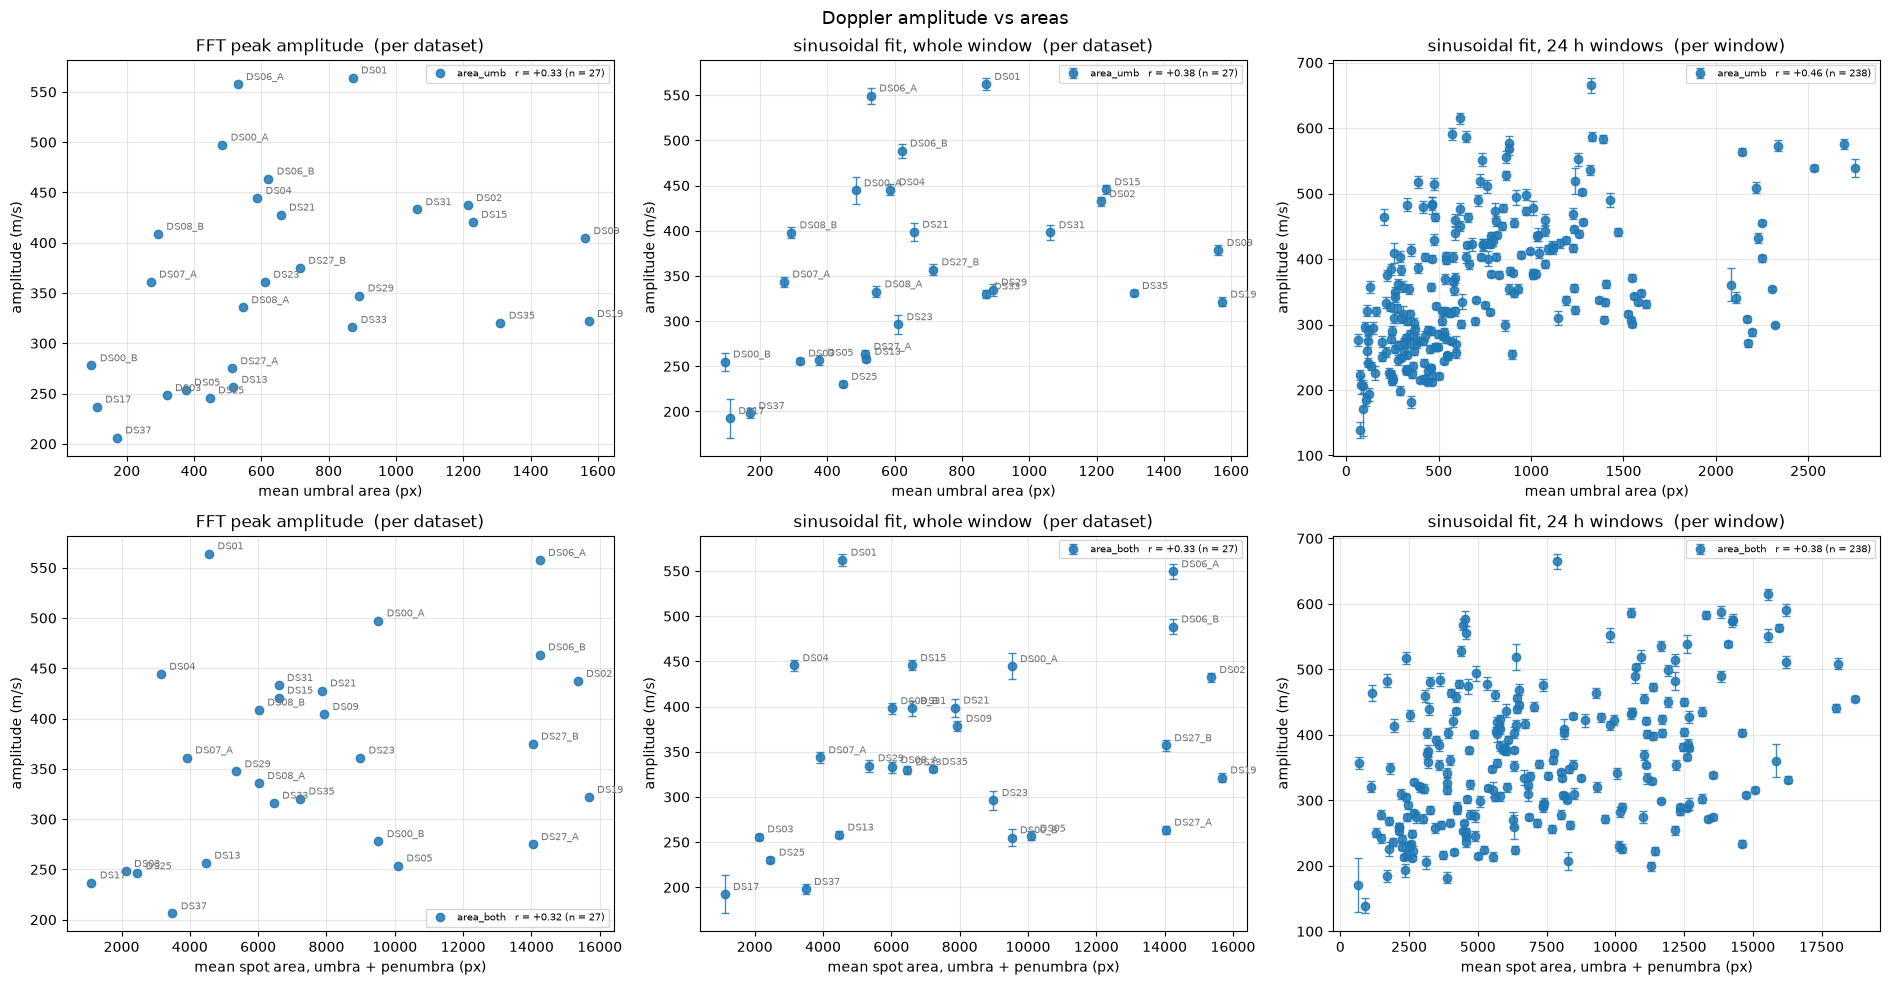

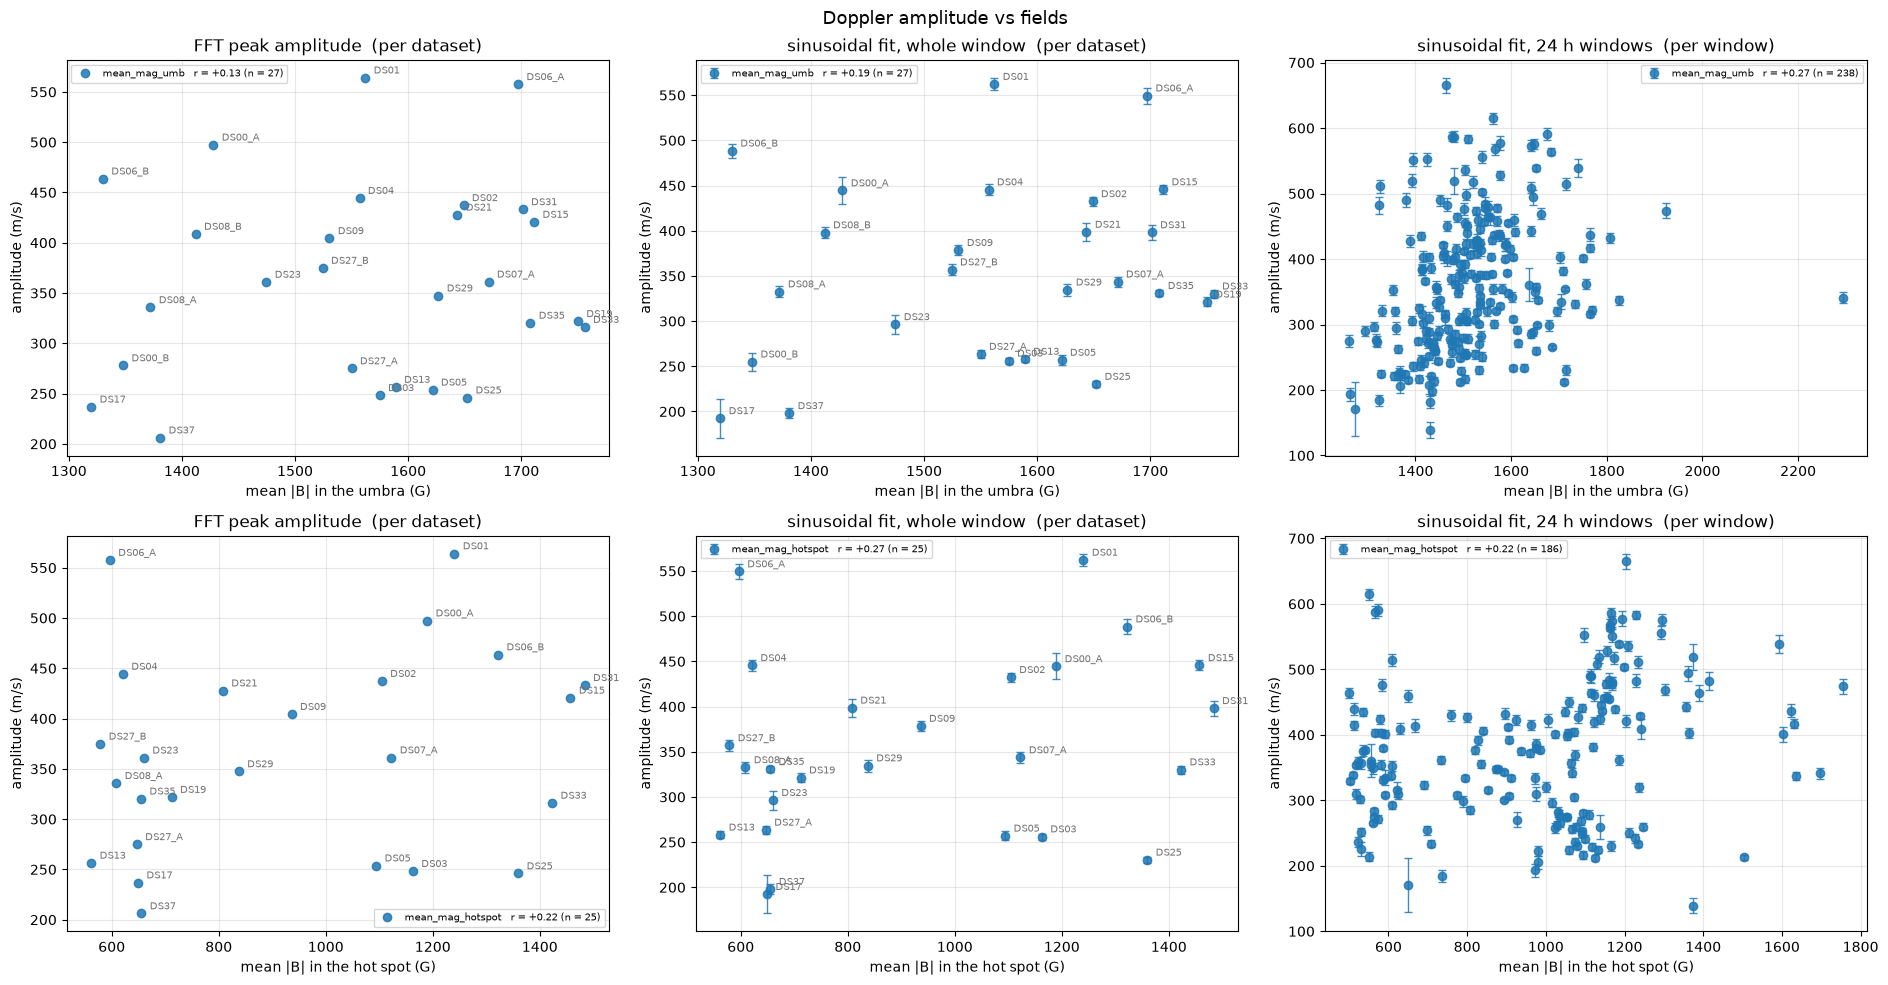

In [36]:
# One predictor per panel: `area_both` runs an order of magnitude above `area_umb`, so
# sharing an x axis squashed the umbral points against the left edge. Rows are the predictor,
# columns the three amplitudes — the FFT peak, the whole-window fit, and the per-24 h-window fit.
AMPLITUDES = [(osc,   'fft_amplitude', None,              'dataset',
               'FFT peak amplitude  (per dataset)'),
              (osc,   'fit_amplitude', 'fit_sigma',       'dataset',
               'sinusoidal fit, whole window  (per dataset)'),
              (osc24, 'amplitude',     'sigma_amplitude', None,
               'sinusoidal fit, 24 h windows  (per window)')]

FAMILIES = [('areas',  [('area_umb', 'mean umbral area (px)'),
                        ('area_both', 'mean spot area, umbra + penumbra (px)')]),
            ('fields', [('mean_mag_umb', 'mean |B| in the umbra (G)'),
                        ('mean_mag_hotspot', 'mean |B| in the hot spot (G)')])]

for name, predictors in FAMILIES:
    fig, axes = plt.subplots(len(predictors), len(AMPLITUDES),
                             figsize=(19, 5 * len(predictors)))
    for row, (key, xlabel) in enumerate(predictors):
        for col, (frame, y_key, yerr_key, annotate_key, title) in enumerate(AMPLITUDES):
            comparison.plot_amplitude_vs_predictors(
                frame, [key], y_key, yerr_key=yerr_key, ax=axes[row, col],
                annotate_key=annotate_key, xlabel=xlabel, title=title)
    fig.suptitle(f'Doppler amplitude vs {name}', fontsize=13)
    plt.tight_layout()
    if SAVE:
        fig.savefig(config.DS0N_PROCESSED_DIR / 'plots' / f'amplitude_vs_{name}.png', dpi=150)
    plt.show()

scored 27 of 27 datasets


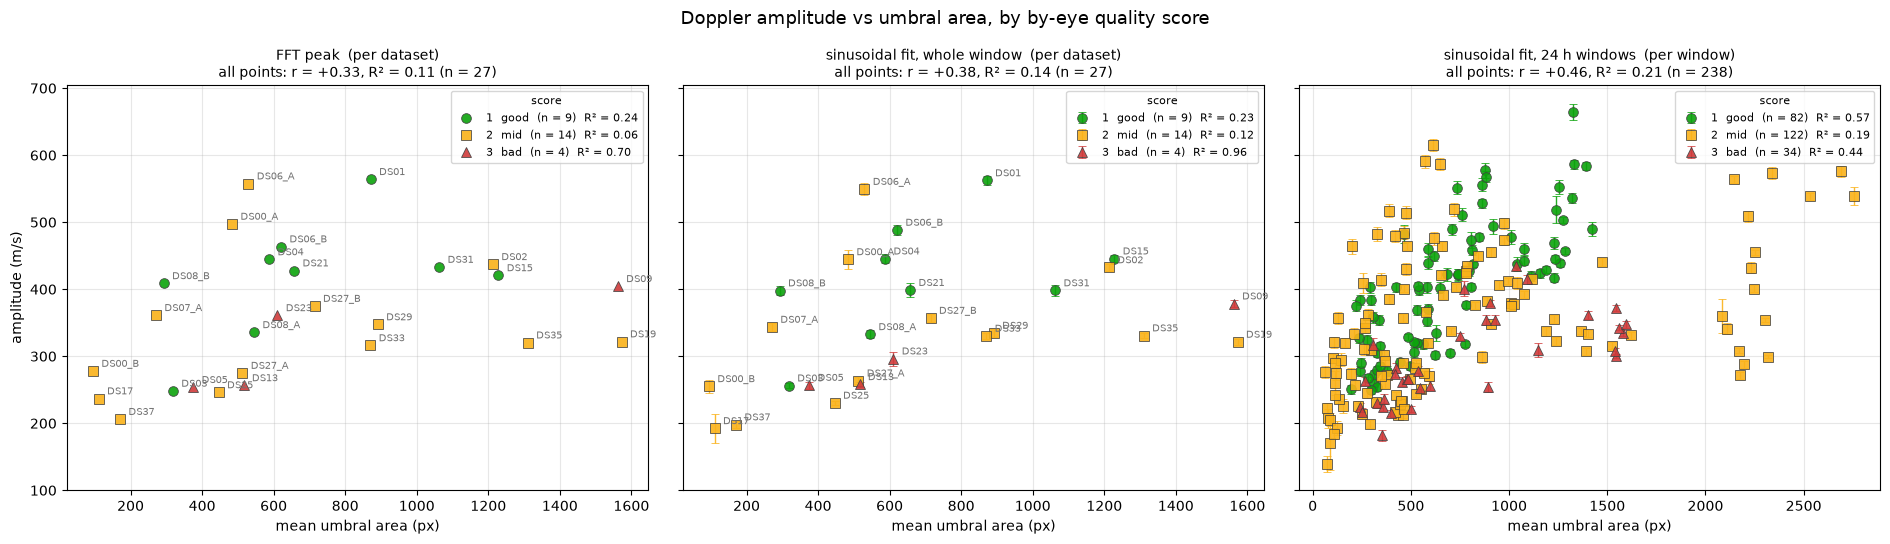


R² of amplitude on mean umbral area, per score category
panel             amplitude  fft_amplitude  fit_amplitude
score label                                              
NaN   all points      0.209          0.110          0.141
1.0   good            0.566          0.235          0.233
2.0   mid             0.193          0.058          0.124
3.0   bad             0.439          0.700          0.958


In [37]:
# Amplitude vs umbral area for the three estimators, colour-coded by the by-eye
# quality score. The table is pasted in here on purpose: it is a testing overlay,
# nothing in `src/` knows about it and nothing below is imported from elsewhere.
import io
import matplotlib.pyplot as plt

# Verbatim, as scored. Header renamed to usable column names; SCORE is 1 good,
# 2 mid, 3 bad. Rows with fewer fields just leave the trailing columns empty.
SCORES_CSV = """dataset,cluster_mode,score,notes,findings
DS00_A,Largest,2, umbra slipting and extencion at the end
DS00_B,Largest,2, umbra slipting and samll region ant the start
DS01,Largest,1,OG
DS02,Largest,2, umbra slipting at start,
DS03,Largest,1
DS04,Largest,1
DS05,Largest,3,hard limit used because it was near antoher splot posible spots other spots
DS06_A,Largest,2,umbra spliting at the end
DS06_B,Largest,1, near spots penumbra not constnt
DS07_A,Largest,2, hard limit beacuse near sports another spots are available
DS08_A,Largest,1
DS08_B,Largest,1
DS09,None,3, multiplke spots overlap
DS13,Largest,3, uncorected due to spliting/merging
DS15,Largest,1, simetrical, small mag half
DS17,Largest,2,solvable noisi dataframes, small mag half
DS19,Largest,2,solvable noisi dataframes, small mag half
DS21,Largest,1, asimetrical and other posible spots,small mag half
DS23,Largest,3, very noisi frames other posible sunspots
DS25,Largest,2, asimetrical sunspots orpfram penumbras
DS27_A,Largest,2,penumbra not constant multiple spotos around
DS27_B,Largest,2, penumbra not constant
DS29,None,2, small umbral spliting penumbr not constant
DS31,Largest,1, non simetrical, mag half period on second peak
DS33,Largest,2, penumbra not constant multiple spots around
DS35,None,2, penumbra not constant and umbra merging
DS37,Largest,2, multiple spots other posible spots
"""

scores = pd.read_csv(io.StringIO(SCORES_CSV), skipinitialspace=True)
scores['dataset'] = scores['dataset'].str.strip()

# The table is scored by hand, so say out loud where it and the loaded datasets
# disagree instead of letting a typo quietly drop a point off the plot.
dupes = scores['dataset'][scores['dataset'].duplicated()].tolist()
if dupes:
    print(f'duplicate row(s) in the score table, first kept: {dupes}')
    scores = scores.drop_duplicates('dataset', keep='first')

score_of = scores.set_index('dataset')['score'].astype(int)
unscored = sorted(set(osc['dataset']) - set(score_of.index))
unknown  = sorted(set(score_of.index) - set(osc['dataset']))
print(f'scored {len(set(osc["dataset"]) & set(score_of.index))} of {osc["dataset"].nunique()} datasets')
if unscored:
    print(f'  loaded but not in the table (drawn grey): {unscored}')
if unknown:
    print(f'  in the table but not loaded            : {unknown}')

# Status palette, not a categorical one: the three levels are a state, so the
# colour is the reserved good/warning/critical triple and marker shape carries
# the same information again for anyone who cannot separate the hues.
LEVELS = {1: ('good',  '#0ca30c', 'o'),
          2: ('mid',   '#fab219', 's'),
          3: ('bad',   '#d03b3b', '^')}
GREY = ('unscored', '#9a9a95', 'x')

def r_squared(x, y):
    """R^2 of the least-squares line y = a*x + b, over the finite points only.

    Returned alongside n because with four points in a category R^2 describes
    those four points and nothing else.
    """
    ok = np.isfinite(x) & np.isfinite(y)
    n = int(ok.sum())
    if n < 3:
        return float('nan'), n
    a, b = np.polyfit(x[ok], y[ok], 1)
    ss_res = float(np.sum((y[ok] - (a * x[ok] + b)) ** 2))
    ss_tot = float(np.sum((y[ok] - y[ok].mean()) ** 2))
    return (1.0 - ss_res / ss_tot if ss_tot > 0 else float('nan')), n


PANELS = [(osc,   'fft_amplitude', None,              True,
           'FFT peak  (per dataset)'),
          (osc,   'fit_amplitude', 'fit_sigma',       True,
           'sinusoidal fit, whole window  (per dataset)'),
          (osc24, 'amplitude',     'sigma_amplitude', False,
           'sinusoidal fit, 24 h windows  (per window)')]

fit_rows_by_score = []

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5), sharey=True)
for ax, (frame, y_key, yerr_key, annotate, title) in zip(axes, PANELS):
    level = frame['dataset'].map(score_of)
    x_all = frame['area_umb'].to_numpy(dtype=float)
    y_all = frame[y_key].to_numpy(dtype=float)

    for value, (label, colour, marker) in list(LEVELS.items()) + [(None, GREY)]:
        sel = level.isna().to_numpy() if value is None else (level == value).to_numpy()
        if not sel.any():
            continue
        yerr = (frame[yerr_key].to_numpy(dtype=float)[sel]
                if yerr_key is not None and yerr_key in frame.columns else None)
        # R^2 of amplitude on area *within this category*: how much of the spread
        # the area explains among datasets that were segmented equally well.
        r2, n_fit = r_squared(x_all[sel], y_all[sel])
        fit_rows_by_score.append({'panel': y_key, 'score': value, 'label': label,
                                  'n': n_fit, 'r2': r2})
        ax.errorbar(x_all[sel], y_all[sel], yerr=yerr, fmt=marker, ms=7, lw=0,
                    capsize=3, elinewidth=1, alpha=0.9, color=colour,
                    markeredgecolor='0.25', markeredgewidth=0.6,
                    label=f'{value if value is not None else "-"}  {label}'
                          f'  (n = {n_fit})  R² = {r2:.2f}')

    # r over every point on the panel, the same number the uncoloured version reports,
    # so the per-category numbers can be read against it rather than instead of it.
    ok = np.isfinite(x_all) & np.isfinite(y_all)
    r = float(np.corrcoef(x_all[ok], y_all[ok])[0, 1]) if ok.sum() > 2 else float('nan')
    r2_all, _ = r_squared(x_all, y_all)
    fit_rows_by_score.append({'panel': y_key, 'score': None, 'label': 'all points',
                              'n': int(ok.sum()), 'r2': r2_all})

    if annotate:
        for name, xi, yi in zip(frame['dataset'], x_all, y_all):
            ax.annotate(str(name), (xi, yi), textcoords='offset points', xytext=(6, 3),
                        fontsize=7, color='0.45')

    ax.set_xlabel('mean umbral area (px)')
    ax.set_title(f'{title}\nall points: r = {r:+.2f}, R² = {r2_all:.2f} '
                 f'(n = {int(ok.sum())})', fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, title='score', title_fontsize=8)

axes[0].set_ylabel('amplitude (m/s)')
fig.suptitle('Doppler amplitude vs umbral area, by by-eye quality score', fontsize=13)
plt.tight_layout()
plt.show()

print('\nR² of amplitude on mean umbral area, per score category')
print(pd.DataFrame(fit_rows_by_score)
        .pivot(index=['score', 'label'], columns='panel', values='r2')
        .round(3).to_string())

4 clusters of fft_period_h (k-means, quantile-seeded)
  cluster 0: centre  23.53 h  n = 10  [22.68-23.62 h]  DS37, DS15, DS35, DS07_A, DS05, DS04, DS01, DS03, DS33, DS06_B
  cluster 1: centre  23.80 h  n =  1  [23.80-23.80 h]  DS17
  cluster 2: centre  25.15 h  n = 15  [25.00-26.03 h]  DS27_B, DS27_A, DS13, DS02, DS09, DS19, DS08_A, DS08_B, DS25, DS29, DS21, DS06_A, DS31, DS00_B, DS00_A
  cluster 3: centre  28.69 h  n =  1  [28.69-28.69 h]  DS23

12 distinct period values behind 27 datasets — the FFT grid quantises them, so the clusters are that coarse too.

cluster vs by-eye score:
score    1  2  3
cluster         
0        5  4  1
1        0  1  0
2        4  9  2
3        0  0  1


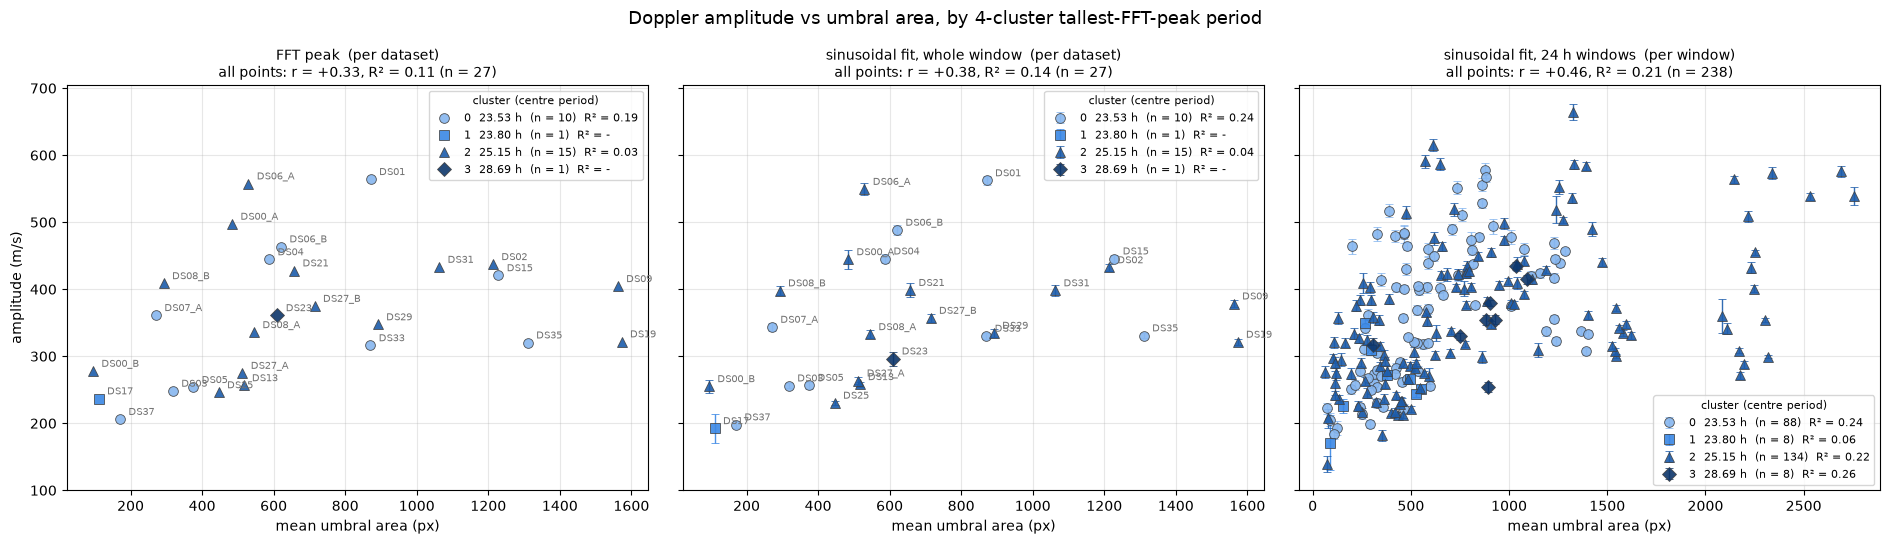


R² of amplitude on mean umbral area, per cluster
panel             amplitude  fft_amplitude  fit_amplitude
cluster centre_h                                         
NaN     NaN           0.209          0.110          0.141
0.0     23.53         0.238          0.189          0.243
1.0     23.80         0.064            NaN            NaN
2.0     25.15         0.225          0.027          0.036
3.0     28.69         0.260            NaN            NaN


In [38]:
# The same three panels as the cell above, with the by-eye score swapped out for
# the cluster as the colour category. Reuses `PANELS` and `r_squared` from that
# cell so the two figures cannot drift apart; `score_of` is only used to report
# how the two categorisations line up.
N_CLUSTERS = 4


def kmeans_1d(values, k, iters=100):
    """Lloyd's algorithm on a single axis, seeded from the k quantiles.

    Deterministic by construction — no random restarts, so re-running the
    notebook cannot silently renumber the clusters. Returns labels ordered by
    centre, so cluster 0 is always the shortest period.
    """
    x = np.asarray(values, dtype=float)
    centres = np.quantile(x, np.linspace(0, 1, 2 * k + 1)[1::2])
    for _ in range(iters):
        labels = np.argmin(np.abs(x[:, None] - centres[None, :]), axis=1)
        moved = np.array([x[labels == j].mean() if np.any(labels == j) else centres[j]
                          for j in range(k)])
        if np.allclose(moved, centres):
            break
        centres = moved
    order = np.argsort(centres)
    remap = np.empty(k, dtype=int)
    remap[order] = np.arange(k)
    return remap[labels], centres[order]


# Cluster the *datasets*, not the windows: `fft_period_h` is one number per
# dataset (a 24 h window is one cycle and has no peak of its own), so osc24 is
# labelled by mapping its dataset column, exactly as cell 26 maps the period.
periods = osc.set_index('dataset')['fft_period_h']
labels, centres = kmeans_1d(periods.to_numpy(), N_CLUSTERS)
cluster_of = pd.Series(labels, index=periods.index)

members = pd.DataFrame({'dataset': periods.index, 'fft_period_h': periods.to_numpy(),
                        'cluster': labels, 'score': periods.index.map(score_of)})
print(f'{N_CLUSTERS} clusters of fft_period_h (k-means, quantile-seeded)')
for j in range(N_CLUSTERS):
    sub = members[members['cluster'] == j].sort_values('fft_period_h')
    print(f'  cluster {j}: centre {centres[j]:6.2f} h  n = {len(sub):2d}  '
          f'[{sub["fft_period_h"].min():.2f}-{sub["fft_period_h"].max():.2f} h]  '
          f'{", ".join(sub["dataset"])}')
print(f'\n{periods.nunique()} distinct period values behind {len(periods)} datasets '
      f'— the FFT grid quantises them, so the clusters are that coarse too.')
print('\ncluster vs by-eye score:')
print(pd.crosstab(members['cluster'], members['score'],
                  rownames=['cluster'], colnames=['score']).to_string())

# An ordinal ramp, not a categorical palette: the clusters are ordered bins of a
# continuous variable, so one hue light->dark says "longer period" the way four
# unrelated hues cannot. Steps start at the light end that still clears contrast
# on a white ground. Marker shape repeats the level for anyone who cannot
# separate the steps by lightness alone.
BLUE_ORDINAL = ['#86b6ef', '#6da7ec', '#5598e7', '#3987e5', '#2a78d6',
                '#256abf', '#1c5cab', '#184f95', '#104281', '#0d366b']
MARKERS = ('o', 's', '^', 'D', 'v', 'P', 'X')
steps = np.linspace(0, len(BLUE_ORDINAL) - 1, N_CLUSTERS).round().astype(int)
CLUSTER_STYLE = {j: (BLUE_ORDINAL[s], MARKERS[j % len(MARKERS)])
                 for j, s in enumerate(steps)}

r2_rows = []
fig, axes = plt.subplots(1, len(PANELS), figsize=(19, 5.5), sharey=True)
for ax, (frame, y_key, yerr_key, annotate, title) in zip(axes, PANELS):
    level = frame['dataset'].map(cluster_of)
    x_all = frame['area_umb'].to_numpy(dtype=float)
    y_all = frame[y_key].to_numpy(dtype=float)

    for j in range(N_CLUSTERS):
        colour, marker = CLUSTER_STYLE[j]
        sel = (level == j).to_numpy()
        if not sel.any():
            continue
        yerr = (frame[yerr_key].to_numpy(dtype=float)[sel]
                if yerr_key is not None and yerr_key in frame.columns else None)
        # R^2 of amplitude on area *within this cluster*: how much of the spread
        # the area explains among datasets oscillating at the same period.
        r2, n_fit = r_squared(x_all[sel], y_all[sel])
        r2_rows.append({'panel': y_key, 'cluster': j, 'centre_h': round(centres[j], 2),
                        'n': n_fit, 'r2': r2})
        ax.errorbar(x_all[sel], y_all[sel], yerr=yerr, fmt=marker, ms=7, lw=0,
                    capsize=3, elinewidth=1, alpha=0.9, color=colour,
                    markeredgecolor='0.25', markeredgewidth=0.6,
                    label=f'{j}  {centres[j]:.2f} h  (n = {n_fit})'
                          + (f'  R² = {r2:.2f}' if np.isfinite(r2) else '  R² = -'))

    ok = np.isfinite(x_all) & np.isfinite(y_all)
    r = float(np.corrcoef(x_all[ok], y_all[ok])[0, 1]) if ok.sum() > 2 else float('nan')
    r2_all, _ = r_squared(x_all, y_all)
    r2_rows.append({'panel': y_key, 'cluster': None, 'centre_h': np.nan,
                    'n': int(ok.sum()), 'r2': r2_all})

    if annotate:
        for name, xi, yi in zip(frame['dataset'], x_all, y_all):
            ax.annotate(str(name), (xi, yi), textcoords='offset points', xytext=(6, 3),
                        fontsize=7, color='0.45')

    ax.set_xlabel('mean umbral area (px)')
    ax.set_title(f'{title}\nall points: r = {r:+.2f}, R² = {r2_all:.2f} '
                 f'(n = {int(ok.sum())})', fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, title='cluster (centre period)', title_fontsize=8)

axes[0].set_ylabel('amplitude (m/s)')
fig.suptitle(f'Doppler amplitude vs umbral area, by {N_CLUSTERS}-cluster '
             f'tallest-FFT-peak period', fontsize=13)
plt.tight_layout()
plt.show()

print('\nR² of amplitude on mean umbral area, per cluster')
print(pd.DataFrame(r2_rows)
        .pivot(index=['cluster', 'centre_h'], columns='panel', values='r2')
        .round(3).to_string())

### Every amplitude against the period it oscillates at

The five amplitude estimators on one x axis: the period of the tallest FFT peak inside the
16–36 h band. The top row is measured once per dataset, the bottom row once per 24 h window —
and the bottom row's x is still the dataset's period, because a single 24 h window is one
cycle and has no spectral peak of its own to measure.

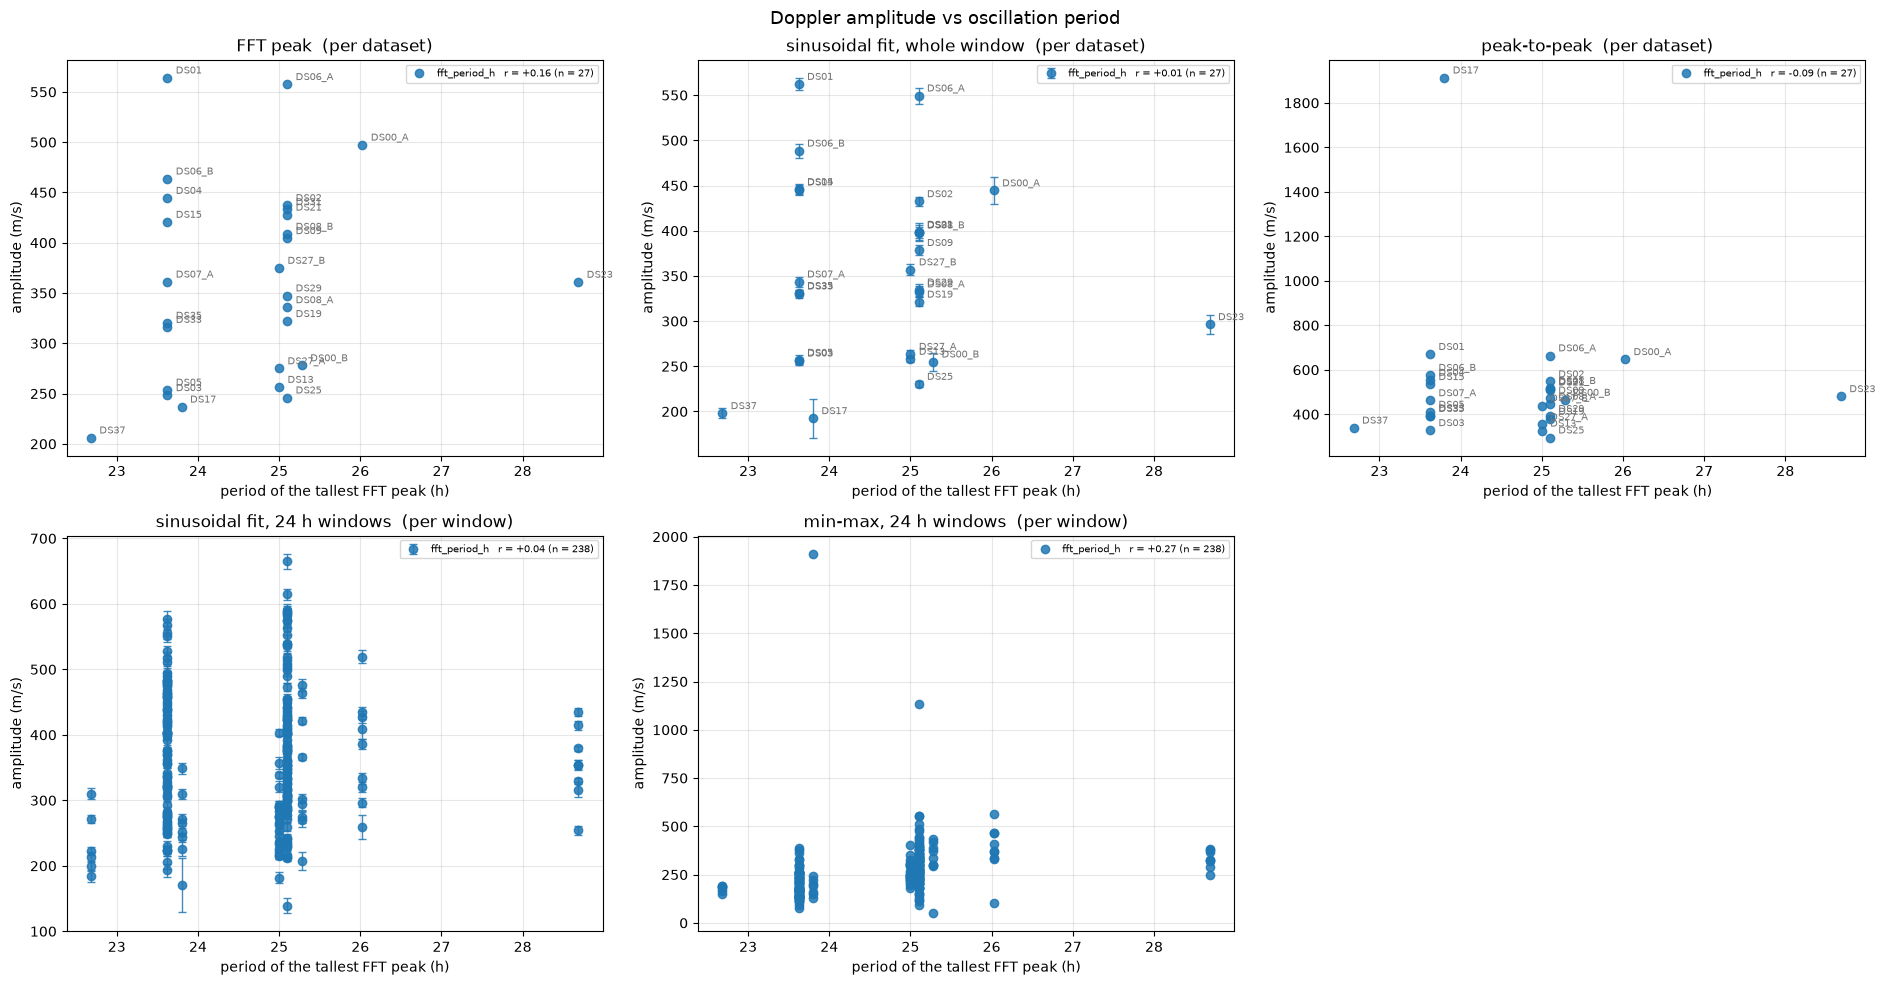

In [39]:
PERIOD_KEY = 'fft_period_h'
ESTIMATORS = [(osc,   'fft_amplitude',    None,              'dataset',
               'FFT peak  (per dataset)'),
              (osc,   'fit_amplitude',    'fit_sigma',       'dataset',
               'sinusoidal fit, whole window  (per dataset)'),
              (osc,   'peak_to_peak',     None,              'dataset',
               'peak-to-peak  (per dataset)'),
              (osc24, 'amplitude',        'sigma_amplitude', None,
               'sinusoidal fit, 24 h windows  (per window)'),
              (osc24, 'minmax_amplitude', None,              None,
               'min-max, 24 h windows  (per window)')]

fig, axes = plt.subplots(2, 3, figsize=(19, 10))
for ax, (frame, y_key, yerr_key, annotate_key, title) in zip(axes.flat, ESTIMATORS):
    comparison.plot_amplitude_vs_predictors(
        frame, [PERIOD_KEY], y_key, yerr_key=yerr_key, ax=ax, annotate_key=annotate_key,
        xlabel='period of the tallest FFT peak (h)', title=title)
axes.flat[-1].remove()          # five estimators, six slots
fig.suptitle('Doppler amplitude vs oscillation period', fontsize=13)
plt.tight_layout()
if SAVE:
    fig.savefig(config.DS0N_PROCESSED_DIR / 'plots' / 'amplitude_vs_period.png', dpi=150)
plt.show()

## Correlations

Now one row per 24 h window rather than one per dataset, which is what takes the sample from a
dozen points to about a hundred. Still a screening tool: it says which pairs are worth a scatter
plot, and nothing more — and `fft_period_h` is the one column that is constant within a dataset,
so its row is a between-dataset effect sitting in a per-window table, not 110 independent points.

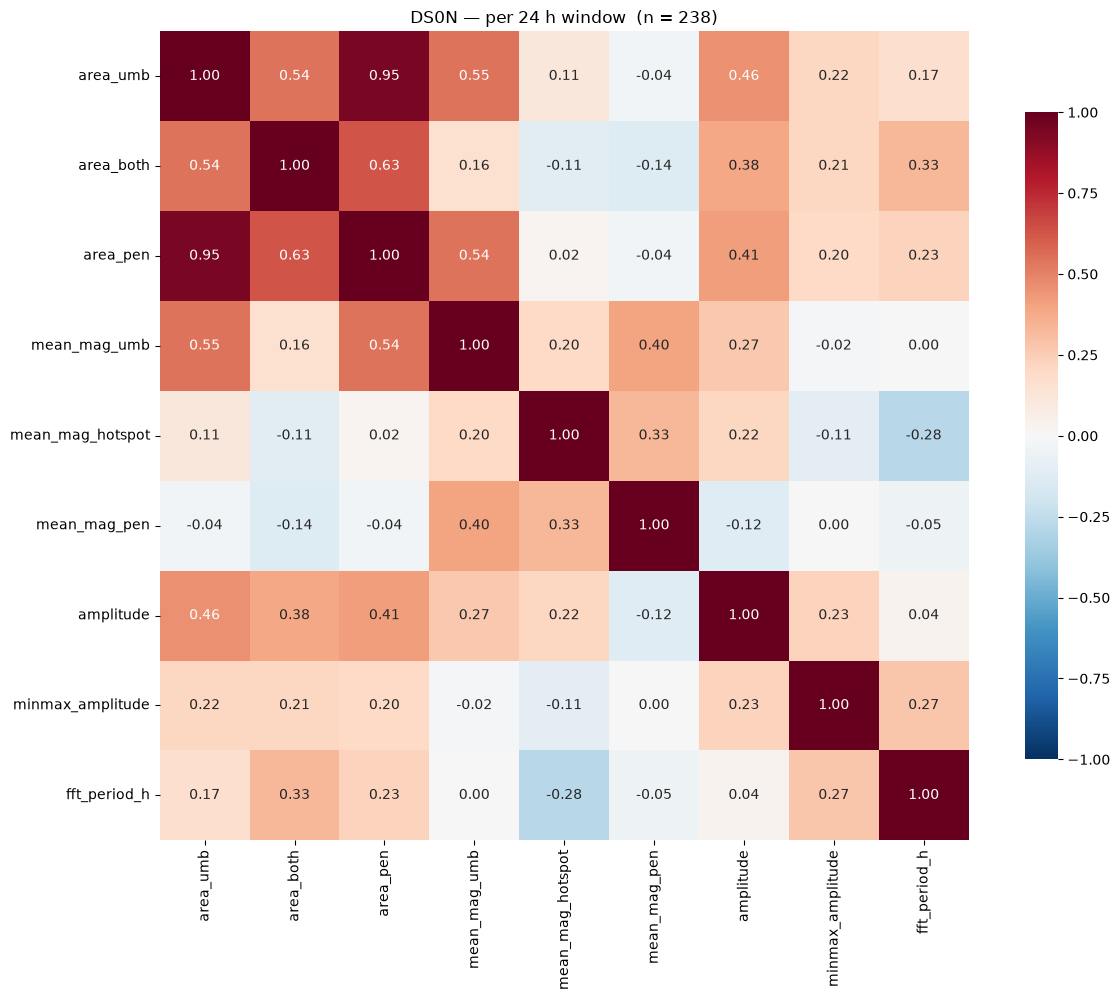

,area_umb,area_both,area_pen,mean_mag_umb,mean_mag_hotspot,mean_mag_pen,amplitude,minmax_amplitude,fft_period_h
area_umb,1.000000,0.539215,0.948601,0.546597,0.111923,-0.038028,0.457473,0.216979,0.170333
area_both,0.539215,1.000000,0.632598,0.160698,-0.113941,-0.139449,0.382953,0.211178,0.334129
area_pen,0.948601,0.632598,1.000000,0.543818,0.024832,-0.038302,0.414072,0.199097,0.230201
mean_mag_umb,0.546597,0.160698,0.543818,1.000000,0.197176,0.402609,0.272017,-0.018207,0.001344
mean_mag_hotspot,0.111923,-0.113941,0.024832,0.197176,1.000000,0.330917,0.216911,-0.108930,-0.278329
mean_mag_pen,-0.038028,-0.139449,-0.038302,0.402609,0.330917,1.000000,-0.117956,0.001192,-0.052717
amplitude,0.457473,0.382953,0.414072,0.272017,0.216911,-0.117956,1.000000,0.229880,0.037248
minmax_amplitude,0.216979,0.211178,0.199097,-0.018207,-0.108930,0.001192,0.229880,1.000000,0.274087
fft_period_h,0.170333,0.334129,0.230201,0.001344,-0.278329,-0.052717,0.037248,0.274087,1.000000


In [40]:
wide = osc24[PREDICTORS + ['amplitude', 'minmax_amplitude', 'fft_period_h']]
comparison.correlation_heatmap(wide, title='DS0N — per 24 h window',
                               save=SAVE, plots_dir=config.DS0N_PROCESSED_DIR / 'plots')

## Spectral peaks across the datasets

`03B` writes a peak table per dataset in step 5. Pooling them shows whether the datasets
agree on which periods exist, or whether each one finds its own.

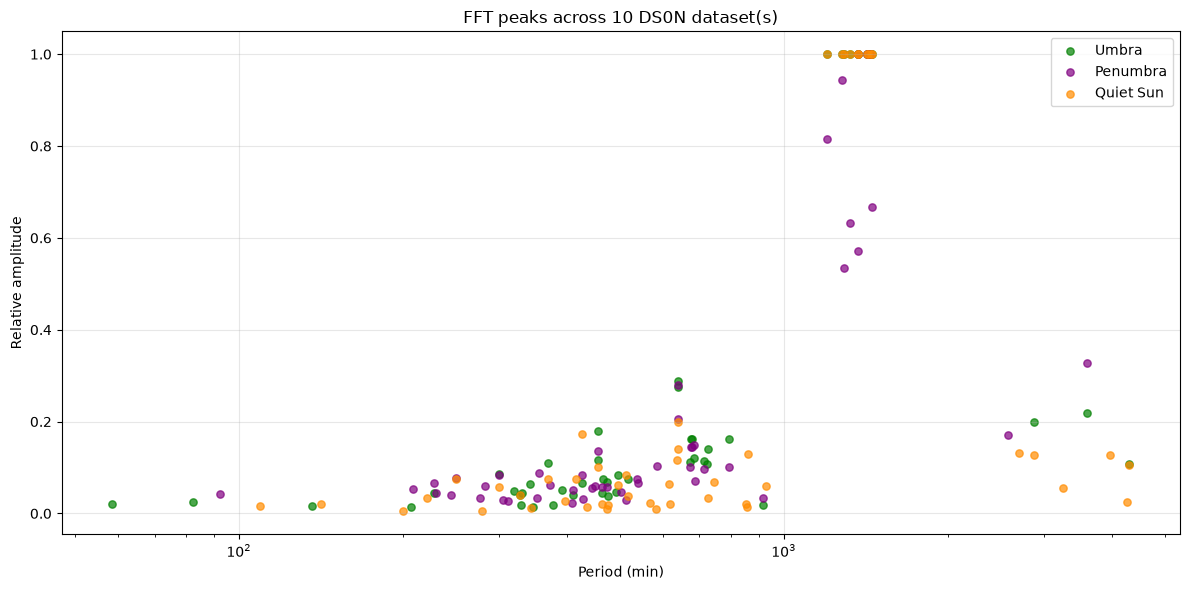

dataset    region  rank  freq_mhz  period_min  relative
   DS00     Umbra     1    0.0139      1201.3    1.0000
   DS00     Umbra     2    0.0046      3604.0    0.2185
   DS00     Umbra     3    0.0247       675.8    0.1611
   DS00     Umbra     4    0.0339       491.5    0.0467
   DS00     Umbra     5    0.0509       327.6    0.0407
   DS00  Penumbra     1    0.0139      1201.3    0.8152
   DS00  Penumbra     2    0.0046      3604.0    0.3268
   DS00  Penumbra     3    0.0247       675.8    0.1456
   DS00  Penumbra     4    0.0370       450.5    0.0591
   DS00  Penumbra     5    0.0725       230.0    0.0441
   DS00      Both     1    0.0139      1201.3    0.9078
   DS00      Both     2    0.0046      3604.0    0.3213
   DS00      Both     3    0.0247       675.8    0.1552
   DS00      Both     4    0.0370       450.5    0.0581
   DS00      Both     5    0.0725       230.0    0.0408
   DS00 Quiet Sun     1    0.0139      1201.3    1.0000
   DS00 Quiet Sun     2    0.0062      2703.0   

In [41]:
peak_frames = []
for ds in DS0N_IDS:
    path = config.DS0N_PROCESSED_DIR / ds / 'plots' / 'fft_peaks.csv'
    if path.exists():
        df = pd.read_csv(path)
        # Peak tables written before the spectra merge call the column `rel_amplitude`;
        # `spectra.save_peak_table` now writes `relative`, because the same table also
        # holds relative *power* when the spectrum is a PSD. Accept either, so files
        # already on disk stay readable without re-running 03B.
        if 'relative' not in df.columns and 'rel_amplitude' in df.columns:
            df = df.rename(columns={'rel_amplitude': 'relative'})
        df.insert(0, 'dataset', ds)
        peak_frames.append(df)

if peak_frames:
    peaks = pd.concat(peak_frames, ignore_index=True)
    fig, ax = plt.subplots(figsize=(12, 6))
    for region, colour in [('Umbra', 'green'), ('Penumbra', 'purple'),
                           ('Quiet Sun', 'darkorange')]:
        sub = peaks[peaks['region'] == region]
        ax.scatter(sub['period_min'], sub['relative'], s=28, alpha=0.7,
                   color=colour, label=region)
    ax.set_xscale('log')
    ax.set_xlabel('Period (min)')
    ax.set_ylabel('Relative amplitude')
    ax.set_title(f'FFT peaks across {peaks["dataset"].nunique()} DS0N dataset(s)')
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(peaks.head(20).to_string(index=False))
else:
    print('No fft_peaks.csv found — run 03B step 5 with SAVE = True first.')

---

## Where this leaves things

- The umbra and the penumbra move differently from the quiet sun, but the quiet sun's own
  24 h signal is large enough that the *absolute* umbral amplitude is not a measurement of
  the sunspot. The `umbra − quiet` column is the one to quote.
- That the quiet-sun oscillation comes out in antiphase suggests the cleaning removed more
  than it should have. Subtracting the quiet-sun cube from the region cubes directly, rather
  than subtracting per-frame means, would give relative velocities and is the obvious next
  step.
- The magnetogram residual and the Doppler signal share a period. Whether they are genuinely
  in phase, and whether that survives the μ (geometry) check in step 7 of `03A`/`03B`, is
  still open — see `03T_analysis_sandbox.ipynb`.